<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen "Papulator" auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 29.04.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)
    * [Aufgabe 5](#Aufgabe-5)
    * [Aufgabe 6](#Aufgabe-6)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [233]:
versuchsnummer = "242"
versuchsname = "Operationsverstaerker" 
aufgabe = "0z"
plt_save_folder = f"../img/plots/"

# Import aller genutzen Libaries

In [234]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

<hr>

## Aufgabe 1

In [235]:
def linear(a, x, b):
    return a * x + b

<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_8424/1781881936.py:11: SyntaxWarning: invalid escape sequence '\O'
  ohm = '$\Omega$'


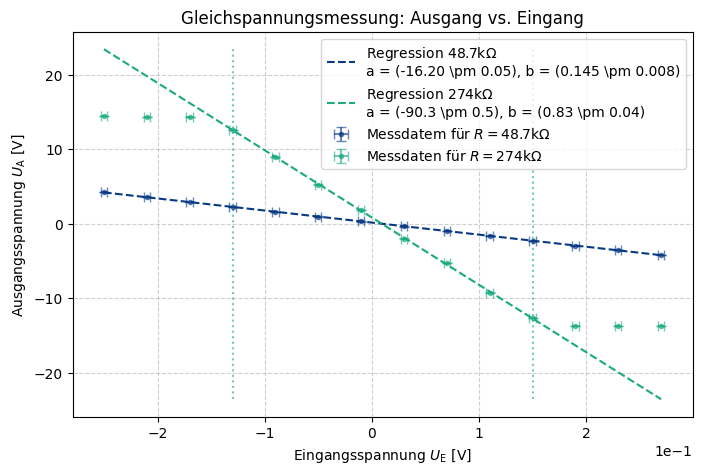

<Axes: title={'center': 'Gleichspannungsmessung: Ausgang vs. Eingang'}, xlabel='Eingangsspannung $U_\\text{E}$ [V]', ylabel='Ausgangsspannung $U_\\text{A}$ [V]'>

In [236]:
aufgabe = '1a'

# Daten laden
gl_V = pd.read_csv('A1/GL-V.csv', engine='python', header=0, skip_blank_lines=True)

# Fehlerdefinitionen 
err_U_E = 3 * 1e-3 
err_U_A1 = 0.01 
err_U_A2 = 0.01 

ohm = '$\Omega$'

# Plot
plt.figure(figsize=(8, 5))

# 1. Daten für R = 48.7 kOhm
x1 = gl_V['U_E [mV]'] * 1e-3  # Umrechnung in Volt
y1 = gl_V['U_A1 48.7K [V]']

plt.errorbar(
    x1, 
    y1, 
    err_U_A1,
    err_U_E,
    label=r'Messdatem für $R = 48.7 \text{k}\Omega$', 
    marker='.', 
    ls='',
    alpha=0.6, 
    color=c.BLUE,
    capsize=3.5
    )

# Lineare Regression für Datensatz 1
popt1, pcov1 = curve_fit(linear, x1, y1)
a1, b1 = popt1
sig_a1 = sqrt(pcov1[0, 0])
sig_b1 = sqrt(pcov1[1, 1])

# Linie für Datensatz 1 zeichnen
x_line1 = np.linspace(min(x1), max(x1), 100)
y_line1 = linear(x_line1, a1, b1)
plt.plot(
    x_line1,
    y_line1, 
    '--', 
    color=c.BLUE, 
    label=f'Regression 48.7k{ohm} \na = ({pap.round_sig_digs(sig_a1, a1)[2]}), b = ({pap.round_sig_digs(sig_b1, b1)[2]})'
    )


# 2. Daten für R = 274 kOhm
x2_full = gl_V['U_E [mV]'] * 1e-3 # Vollständige Eingangsdaten
y2_full = gl_V['U_A2 274K [V]'] # Vollständige Ausgangsdaten

# Index 3 bis -3 da hier in Sättigung
x2 = x2_full[3:-3]
y2 = y2_full[3:-3]

plt.errorbar(
    x2_full, 
    y2_full, 
    err_U_A2,
    err_U_E,
    label=r'Messdaten für $R = 274 \text{k}\Omega$', 
    marker='.',
    ls='',
    alpha=0.6, 
    color=c.LIGHT_GREEN,
    capsize=3.5
    )

# Lineare Regression für Datensatz 2
popt2, pcov2 = curve_fit(linear, x2, y2)
a2, b2 = popt2
sig_a2 = sqrt(pcov2[0, 0])
sig_b2 = sqrt(pcov2[1, 1])

# Linie für Datensatz 2 zeichnen
x_line2 = np.linspace(min(x2_full), max(x2_full), 100)
y_line2 = linear(x_line2, a2, b2)
plt.plot(
    x_line2, 
    y_line2, 
    '--', 
    color=c.LIGHT_GREEN, 
    label=f'Regression 274k{ohm} \na = ({pap.round_sig_digs(sig_a2, a2)[2]}), b = ({pap.round_sig_digs(sig_b2, b2)[2]})'
    )

plt.vlines(
    x2_full[3],
    min(y_line2),
    max(y_line2),
    ls = ':',
    color = c.LIGHT_GREEN,
    alpha = 0.6
)

plt.vlines(
    x2_full[len(x2_full) - 4],
    min(y_line2),
    max(y_line2),
    ls = ':',
    color = c.LIGHT_GREEN,
    alpha = 0.6
)

pap.plot_me('Gleichspannungsmessung: Ausgang vs. Eingang', r'Eingangsspannung $U_\text{E}$ [V]', r'Ausgangsspannung $U_\text{A}$ [V]', fr'{plt_save_folder}gl_V_reg_{aufgabe}')

In [237]:
# Theoretische Werte
sym_R_g, sym_R_e = sp.symbols(r'R_\text{g}, R_\text{E}')
V_prime = sym_R_g / sym_R_e

R_g1 = 48.7
err_R_g1 = R_g1 * 0.1

R_g2 = 274
err_R_g2 = R_g2 * 0.1

R_e = 3
err_R_e = 0.3

values = np.array([
    [R_g1, err_R_g1, R_e, err_R_e],
    [R_g2, err_R_g2, R_e, err_R_e]
])

res = pap.do_it(V_prime, [sym_R_g, sym_R_e], values, [], False)

val_1 = res[0][0]
err_1 = res[0][1]
val_2 = res[1][0]
err_2 = res[1][1]

# print(fr'R=48.7: {pap.round_sig_digs(err_1,val_1)[2]}')
# print(fr'R=274:  {pap.round_sig_digs(err_2,val_2)[2]}')

# print('-' * 20)

# print(fr'R=48.7: \sigma = {pap.std_abw(res[0][1], a1, res[0][0], sig_a1)}')
# print(fr'R=274: \sigma = {pap.std_abw(res[1][1], a2, res[1][0], sig_a2)}')

# print('-' * 20, '\n')


sigma_1 = pap.std_abw(err_1, a1, val_1, sig_a1)
sigma_2 = pap.std_abw(err_2, a2, val_2, sig_a2)

data = {
    r"R_\text{g} [\mathrm{k\Omega}]": [pap.round_sig_digs(err_R_g1, R_g1)[2], pap.round_sig_digs(err_R_g2, R_g2)[2]],
    r"V_{t}": [pap.round_sig_digs(err_1, val_1)[2], pap.round_sig_digs(err_2, val_2)[2]],
    r"\text{Steigung } a": [pap.round_sig_digs(sig_a1, a1)[2], pap.round_sig_digs(sig_a2, a2)[2]],
    r"\text{Std.Abw. } \sigma": [f"{sigma_1:.2f}", f"{sigma_2:.2f}"]
}

df = pd.DataFrame(data)

latex_table = df.to_latex(
    column_format='L | C C || C',
    index=False, 
    escape=False, 
    caption="Vergleich der experimentellen und theoretischen Werte bei Gleichstrom", 
    label="tab:comparison",
    )

print(latex_table)

\begin{table}
\caption{Vergleich der experimentellen und theoretischen Werte bei Gleichstrom}
\label{tab:comparison}
\begin{tabular}{L | C C || C}
\toprule
R_\text{g} [\mathrm{k\Omega}] & V_{t} & \text{Steigung } a & \text{Std.Abw. } \sigma \\
\midrule
49 \pm 5 & 16.2 \pm 2.3 & -16.20 \pm 0.05 & 1.14 \\
270 \pm 30 & 91 \pm 13 & -90.3 \pm 0.5 & 1.13 \\
\bottomrule
\end{tabular}
\end{table}



   Messung  U_G [V_ss]  U_A [V]  U_A1 680K [V]  U_A2 274K [V]
0        1        0.05   0.0432          0.872           0.36
1        2        0.20   0.1680          3.520           1.44
2        3        0.35   0.2920          6.120           2.52
3        4        0.50   0.4200          8.800           3.60
4        5        0.65   0.5440         11.300           4.64
5        6        0.80   0.6640         13.800           5.76
6        7        0.95   0.8000         16.600           6.80
7        8        1.10   0.9200         19.300           7.80


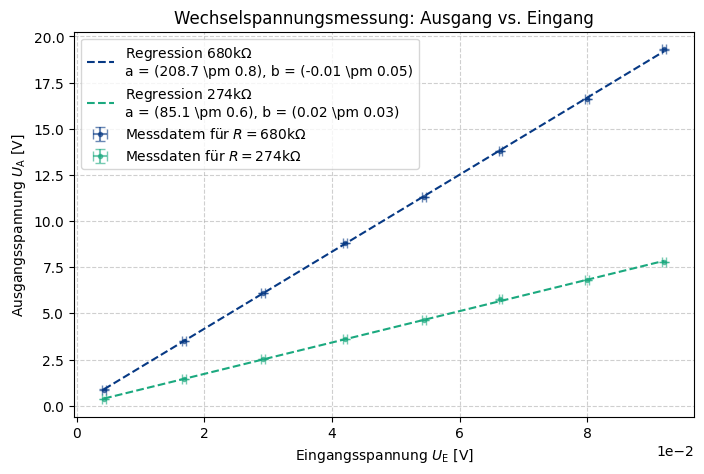

<Axes: title={'center': 'Wechselspannungsmessung: Ausgang vs. Eingang'}, xlabel='Eingangsspannung $U_\\text{E}$ [V]', ylabel='Ausgangsspannung $U_\\text{A}$ [V]'>

In [250]:
aufgabe = '1b'
# Messwerte für die Gleichspannung
we_V = pd.read_csv('A1/We-V.csv', engine='python', header=0, skip_blank_lines=True)

err_U_E = 3 * 1e-3 / 10 # mV in V
err_U_A1 = 0.01 # V
err_U_A2 = 0.01 # V

print(we_V)

# Plot
plt.figure(figsize=(8, 5))

# 1. Daten für R = 680 kOhm
x1 = we_V['U_G [V_ss]'] 
x1 = we_V['U_A [V]'] / 10
y1 = we_V['U_A1 680K [V]']

plt.errorbar(
    x1, 
    y1, 
    err_U_A1,
    err_U_E,
    label=r'Messdatem für $R = 680 \text{k}\Omega$', 
    marker='.', 
    ls='',
    alpha=0.6, 
    color=c.BLUE,
    capsize=3.5
    )

# Lineare Regression für Datensatz 1
popt1, pcov1 = curve_fit(linear, x1, y1)
a1, b1 = popt1
sig_a1 = sqrt(pcov1[0, 0])
sig_b1 = sqrt(pcov1[1, 1])

# Linie für Datensatz 1 zeichnen48.7
x_line1 = np.linspace(min(x1), max(x1), 100)
y_line1 = linear(x_line1, a1, b1)
plt.plot(
    x_line1,
    y_line1, 
    '--', 
    color=c.BLUE, 
    label=f'Regression 680k{ohm} \na = ({pap.round_sig_digs(sig_a1, a1)[2]}), b = ({pap.round_sig_digs(sig_b1, b1)[2]})'
    )


# 2. Daten für R = 274 kOhm
x2_full = we_V['U_G [V_ss]'] / 10
x2_full = we_V['U_A [V]'] / 10
y2_full = we_V['U_A2 274K [V]'] 

plt.errorbar(
    x2_full, 
    y2_full, 
    err_U_A2,
    err_U_E,
    label=r'Messdaten für $R = 274 \text{k}\Omega$', 
    marker='.',
    ls='',
    alpha=0.6, 
    color=c.LIGHT_GREEN,
    capsize=3.5
    )

# Lineare Regression für Datensatz 2
popt2, pcov2 = curve_fit(linear, x2_full, y2_full)
a2, b2 = popt2
sig_a2 = sqrt(pcov2[0, 0])
sig_b2 = sqrt(pcov2[1, 1])

# Linie für Datensatz 2 zeichnen
x_line2 = np.linspace(min(x2_full), max(x2_full), 100)
y_line2 = linear(x_line2, a2, b2)
plt.plot(
    x_line2, 
    y_line2, 
    '--', 
    color=c.LIGHT_GREEN, 
    label=f'Regression 274k{ohm} \na = ({pap.round_sig_digs(sig_a2, a2)[2]}), b = ({pap.round_sig_digs(sig_b2, b2)[2]})'
    )


pap.plot_me('Wechselspannungsmessung: Ausgang vs. Eingang', r'Eingangsspannung $U_\text{E}$ [V]', r'Ausgangsspannung $U_\text{A}$ [V]', fr'{plt_save_folder}we_V_reg_{aufgabe}')

In [251]:
# Theoretische Werte
sym_R_g, sym_R_e = sp.symbols(r'R_\text{g}, R_\text{E}')
V_prime = sym_R_g / sym_R_e

R_g1 = 680
err_R_g1 = R_g1 * 0.1

R_g2 = 274
err_R_g2 = R_g2 * 0.1

R_e = 3
err_R_e = 0.3

values = np.array([
    [R_g1, err_R_g1, R_e, err_R_e],
    [R_g2, err_R_g2, R_e, err_R_e]
])

res = pap.do_it(V_prime, [sym_R_g, sym_R_e], values, [], False)
# print(fr'R=680: {pap.round_sig_digs(res[0][1],res[0][0])[2]}')
# print(fr'R=274:  {pap.round_sig_digs(res[1][1],res[1][0])[2]}')

val_1 = res[0][0]
err_1 = res[0][1]
val_2 = res[1][0]
err_2 = res[1][1]

sigma_1 = pap.std_abw(err_1, a1, val_1, sig_a1)
sigma_2 = pap.std_abw(err_2, a2, val_2, sig_a2)

data = {
    r"R_\text{g} [\mathrm{k\Omega}]": [pap.round_sig_digs(err_R_g1, R_g1)[2], pap.round_sig_digs(err_R_g2, R_g2)[2]],
    r"V_{t}": [pap.round_sig_digs(err_1, val_1)[2], pap.round_sig_digs(err_2, val_2)[2]],
    r"\text{Steigung } a": [pap.round_sig_digs(sig_a1, a1)[2], pap.round_sig_digs(sig_a2, a2)[2]],
    r"\text{Std.Abw. } \sigma": [f"{sigma_1:.2f}", f"{sigma_2:.2f}"]
}

df = pd.DataFrame(data)

latex_table = df.to_latex(
    column_format='L | C C || C',
    index=False, 
    escape=False, 
    caption="Vergleich der experimentellen und theoretischen Werte bei Gleichstrom", 
    label="tab:comparison_WE",
    )

print(latex_table)

\begin{table}
\caption{Vergleich der experimentellen und theoretischen Werte bei Gleichstrom}
\label{tab:comparison_WE}
\begin{tabular}{L | C C || C}
\toprule
R_\text{g} [\mathrm{k\Omega}] & V_{t} & \text{Steigung } a & \text{Std.Abw. } \sigma \\
\midrule
680 \pm 70 & 230 \pm 30 & 208.7 \pm 0.8 & 0.78 \\
270 \pm 30 & 91 \pm 13 & 85.1 \pm 0.6 & 0.79 \\
\bottomrule
\end{tabular}
\end{table}



<hr>

## Aufgabe 2

In [305]:
# Import der Messdaten
VG03 = pd.read_csv('A2/V_G03.csv')
U_G_03 = 0.3
freq_03 = VG03['Frequenz [Hz]']
U1_03 = VG03['U_A 680k [V]']
U2_03 = VG03['U_A 274K [V]']

# Paralell Kondensator
VG1 = pd.read_csv('A2/V_G1.csv')
U_G_1 = 1
freq_1 = VG1['Frequenz [Hz]']
U1_1 = VG1['U_A 48.7k [V]']
U2_1 = VG1['U_A 48.7k und 560pF [V]']

# Paralell Kondensator plus Hochpassfilter
VG1_para = pd.read_csv('A2/V_G1-Parallel.csv')
freq_1_para = VG1_para['Frequenz [Hz]']
U1_1_para = VG1_para['U_A 48.7k und 560pF [V]']

err_U_G = 0.003 # V
err_U_A = 0.01 # V

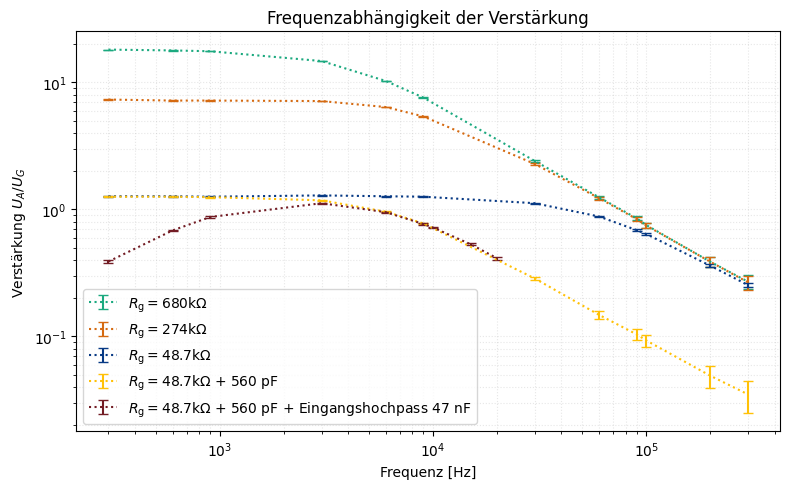

In [317]:
aufgabe = '2a'
plt.figure(figsize=(8, 5))

# 1) R_\text{g} = 680k
plt.errorbar(
    freq_03, 
    U1_03 / U_G_03, 
    xerr=None, 
    yerr=err_U_A / U_G_03,
    ls=':', 
    
    capsize=3.5,
    label=r'$R_\text{g} = 680 \mathrm{k\Omega}$'
    )

# 2) R_\text{g} = 274k
plt.errorbar(
    freq_03, 
    U2_03 / U_G_03, 
    xerr=None, yerr=err_U_A / U_G_03,
    ls=':', 
    
    capsize=3.5,
    label=r'$R_\text{g} = 274 \mathrm{k\Omega}$'
    )

# 3) R_\text{g} = 48.7k (ohne C)
plt.errorbar(
    freq_1, 
    U1_1 / U_G_1,
    xerr=None, 
    yerr=err_U_A / U_G_1,
    ls=':', 
    
    capsize=3.5,
    label=r'$R_\text{g} = 48.7 \mathrm{k\Omega}$'
    )

# 4) R_\text{g} = 48.7k + 560 pF
plt.errorbar(
    freq_1, 
    U2_1 / U_G_1,
    xerr=None, 
    yerr=err_U_A / U_G_1,
    ls=':', 
    capsize=3.5,
    label=r'$R_\text{g} = 48.7 \mathrm{k\Omega}$ + 560 pF',
    color = c.YELLOW
    )

# 5) R_\text{g} = 48.7k + 560 pF + Hochpass
plt.errorbar(
    freq_1_para,
    U1_1_para / U_G_1,
    xerr=None, 
    yerr=err_U_A / U_G_1,
    ls=':', 
    capsize=3.5,
    label=r'$R_\text{g} = 48.7 \mathrm{k\Omega}$ + 560 pF + Eingangshochpass 47 nF',
    color = c.WINE_RED
    )

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Verstärkung $U_A / U_G$')
plt.title('Frequenzabhängigkeit der Verstärkung')
plt.grid(True, which='both', ls=':', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(fr'{plt_save_folder}_Frequenzgang_{aufgabe}.pdf', dpi = 300)

plt.show()